In [3]:
# Loading stored variables from model_training.ipynb
%store -r results_orig
%store -r results_aug

In [13]:
%store -r X_test_aug y_test_aug

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
import joblib

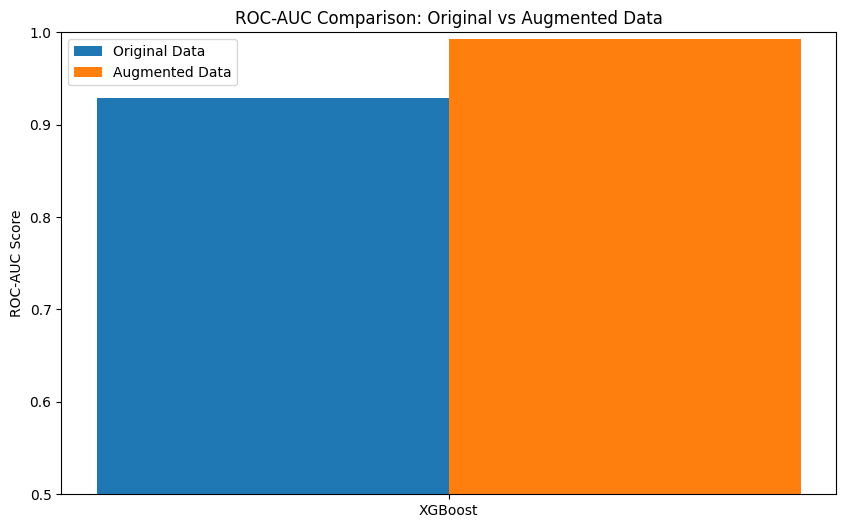

In [7]:
# Visualization - ROC AUC comparison bar chart for XGBoost Model
name = 'XGBoost'
roc_auc_orig = [results_orig[name]['roc_auc']]
roc_auc_aug = [results_aug[name]['roc_auc']]

plt.figure(figsize=(10,6))
bar_width = 0.35
indices = np.arange(1)

plt.bar(indices, roc_auc_orig, bar_width, label='Original Data')
plt.bar(indices + bar_width, roc_auc_aug, bar_width, label='Augmented Data')

plt.xticks(indices + bar_width / 2, ['XGBoost'])
plt.ylabel('ROC-AUC Score')
plt.ylim(0.5, 1.0)
plt.title('ROC-AUC Comparison: Original vs Augmented Data')
plt.legend()
plt.show()

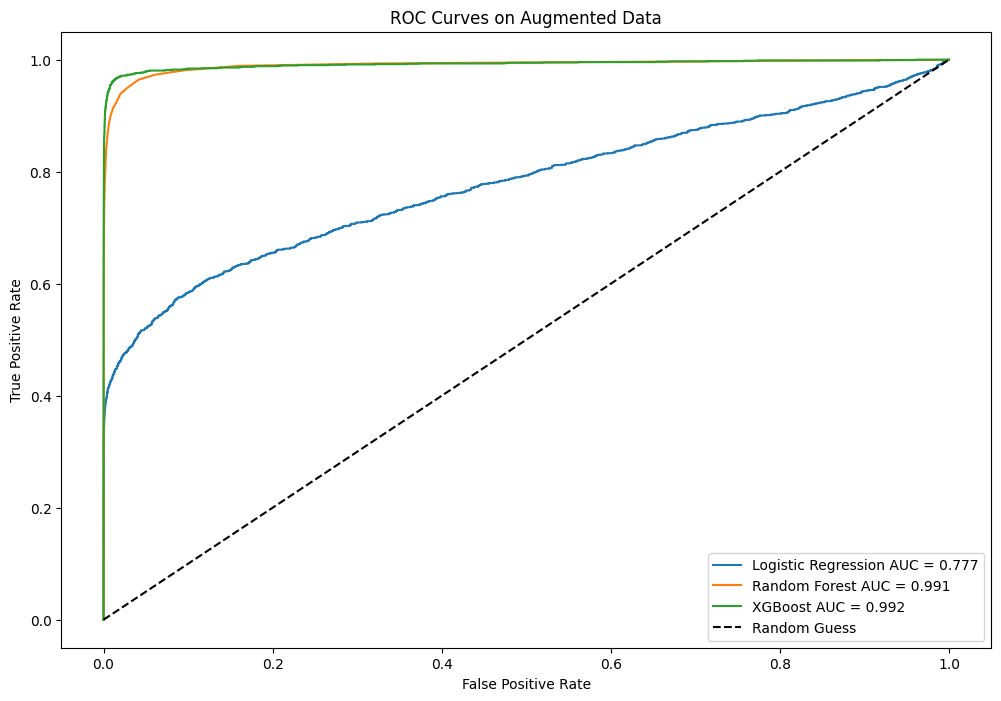

In [11]:
# Visualization - ROC curves for augmented data models
plt.figure(figsize=(12, 8))
model_names = ['Logistic Regression', 'Random Forest', 'XGBoost']
for name in model_names:
    fpr, tpr, _ = roc_curve(y_test_aug, results_aug[name]['probas'])
    roc_auc_val = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} AUC = {roc_auc_val:.3f}')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves on Augmented Data')
plt.legend(loc='lower right')
plt.show()

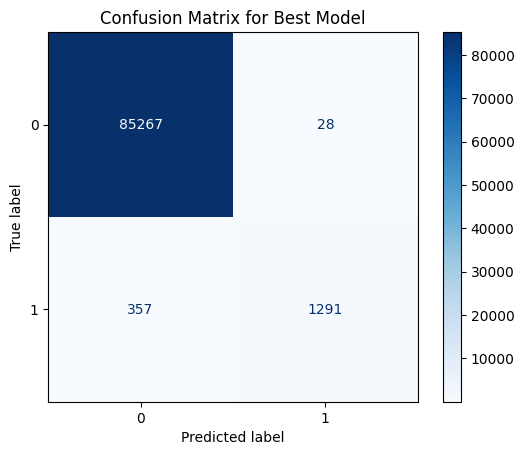

In [16]:
#Load best model
best_model = joblib.load('../Model/credit_card_fraud_detection_model.pkl')
y_pred = best_model.predict(X_test_aug)

# Compute confusion matrix
cm = confusion_matrix(y_test_aug, y_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap=plt.cm.Blues)

plt.title("Confusion Matrix for Best Model")
plt.show()


In [19]:
pd.DataFrame({
    'Model Dataset': ['Real', 'Real + Synthetic'],
    'F1-Score': [results_orig[name]['classification_report']['1']['f1-score'],results_aug[name]['classification_report']['1']['f1-score']],
    'Recall': [results_orig[name]['classification_report']['1']['recall'],results_aug[name]['classification_report']['1']['recall']],
    'Precision': [results_orig[name]['classification_report']['1']['precision'],results_aug[name]['classification_report']['1']['precision']],
    'ROC-AUC': [results_orig[name]['roc_auc'],results_aug[name]['roc_auc']]
})

,Model Dataset,F1-Score,Recall,Precision,ROC-AUC
0,Real,0.838951,0.756757,0.941176,0.928599
1,Real + Synthetic,0.870239,0.783374,0.978772,0.992197


So have a look at this table and it is clearly visible that how adding augmented dataset improved the preprocessed dataset.